# Initialization

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib
importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

#Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
TAS_FORECAST_RAW = os.environ["POREALLAS_TAS_FORECAST_RAW_URI"]

In [3]:
#Projection Effects
effect = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI), consolidated = False)
baseline_period = analysis_utils.get_baseline_period(effect, years = 30)
#Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

#Socioeconomics
socioeconomics =  xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year = 2026)[['pop0to4', 'pop5to64', 'pop65plus', 'pop', 'gdppc', 'iso3']]

# Figure 1
Method Illustration for One Region

# Figure 2

Average forecast temperature anomaly and future year in which it occurs regularly

# Figure 3. 
Aug-Jan cumulative net all-age mortality rate:

In [4]:
#Compute the Mortality Impact relative to a Baseline Period for the Projected Effects
impact = analysis_utils.compute_impact(effect, socioeconomics, ensemble = False, baseline_period=baseline_period, hotonly = "net", rate = True, age_weight = True)

In [8]:
cum_impact = impact.mean(dim = 'sample').sum('month')
_polygons_impact = analysis_utils.xarray_to_gpd(cum_impact, _polygons)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_

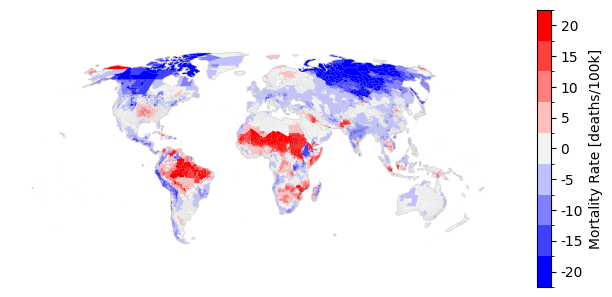

In [10]:
ax = analysis_utils.plot_single(
    _polygons_impact,
    col='age_weighted_impact',
    cm = 'bwr',
    n_colors = 10,
    sup_title=f"",
    cbar_label= "Mortality Rate [deaths/100k]",
)

fig = ax.figure
fig.savefig("fig03_2608_cum_rate.png", dpi = 600, bbox_inches="tight")

# Figure A3. 
Average forecast monthly temperature anomaly

In [49]:
## Raw ##
#Raw Forecast/Hindcast
s51 = xr.open_zarr(os.path.join(DATA_DIR, TAS_FORECAST_RAW))
forecast = s51.sel(time=slice('2026-08-01', '2027-01-31')).groupby("time.month").mean()
hindcast = s51.sel(time=slice('1996-08-01', '2025-12-31')).groupby("time.month").mean().sel(month = [1, 8, 9, 10, 11, 12])

In [46]:
anomaly = forecast['tas']-hindcast['tas']
anomaly.name = "forecast_anomaly"

In [47]:
anomaly_ir = isku_utils.grid_to_ir(anomaly.compute(), savefile = None)
_polygons_anomaly = analysis_utils.xarray_to_gpd(anomaly_ir.mean(dim = 'number'), _polygons)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:33: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


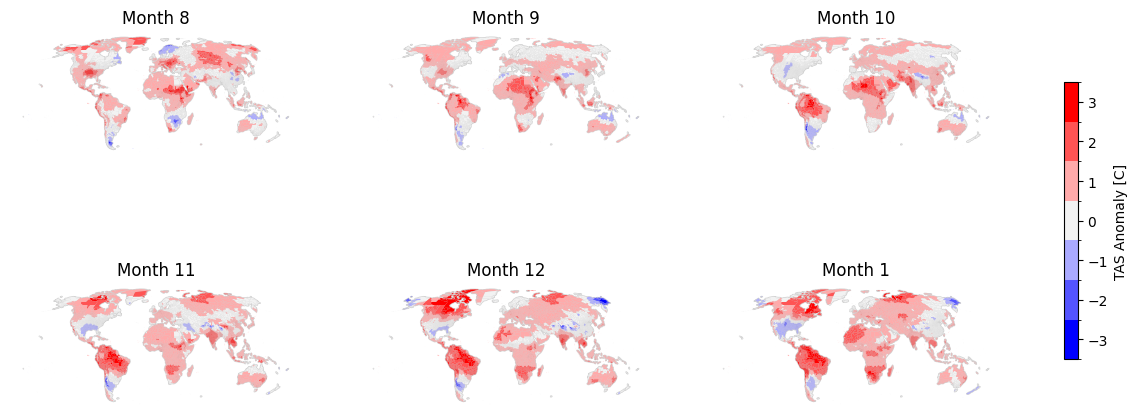

In [48]:
fig = analysis_utils.plot_monthly(
    _polygons_anomaly,
    col='value',
    cm = 'bwr',
    sup_title=f"",
    cbar_label= 'TAS Anomaly [C]',
    month_order= [8, 9, 10, 11, 12, 1]
)
fig.savefig("figA3raw_2608_anomaly.png", dpi = 600, bbox_inches="tight")

In [41]:
## Corrected ##
era5 = xr.open_zarr(os.path.join(DATA_DIR, ERA5_URI)).sel(time = slice("1996-01-01", "2025-12-31"))
forecast = xr.open_zarr(os.path.join(DATA_DIR, TAS_FORECAST_URI))

In [42]:
anomaly_corr = forecast.mean(dim = ['number']).groupby('time.month').mean()-era5.groupby('time.month').mean().sel(month = [8, 9, 10, 11, 12, 1])

In [43]:
# Gridded to Impact Region
anomaly_corr_ir = isku_utils.grid_to_ir(anomaly_corr, savefile = None)
_polygons_anomaly_corr = analysis_utils.xarray_to_gpd(anomaly_corr_ir['tas'], _polygons)


/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:33: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


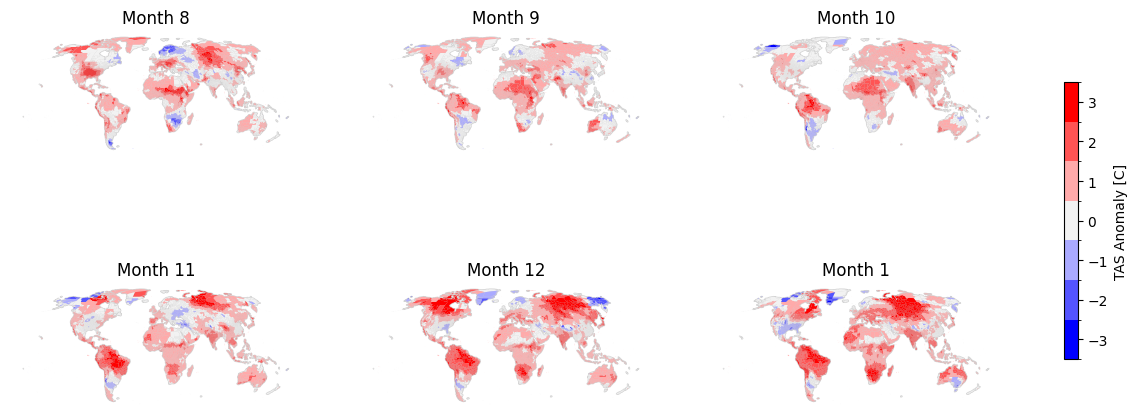

In [44]:
fig = analysis_utils.plot_monthly(
    _polygons_anomaly_corr,
    col='tas',
    cm = 'bwr',
    sup_title=f"",
    cbar_label= 'TAS Anomaly [C]',
    month_order= [8, 9, 10, 11, 12, 1]
)
fig.savefig("figA3era5_2608_anomaly.png", dpi = 600, bbox_inches="tight")

# Figure A4. 
Forecast ensemble 10-90 percentile range in temperature by month:

In [54]:
forecast = s51.sel(time=slice('2026-08-01', '2027-01-31')).groupby("time.month").mean()
forecast_var = forecast['tas'].var(dim = 'number')

In [56]:
# Gridded to Impact Region
forecast_var_ir = isku_utils.grid_to_ir(forecast_var, savefile = None)
_polygons_forecast_var = analysis_utils.xarray_to_gpd(forecast_var_ir, _polygons)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:33: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


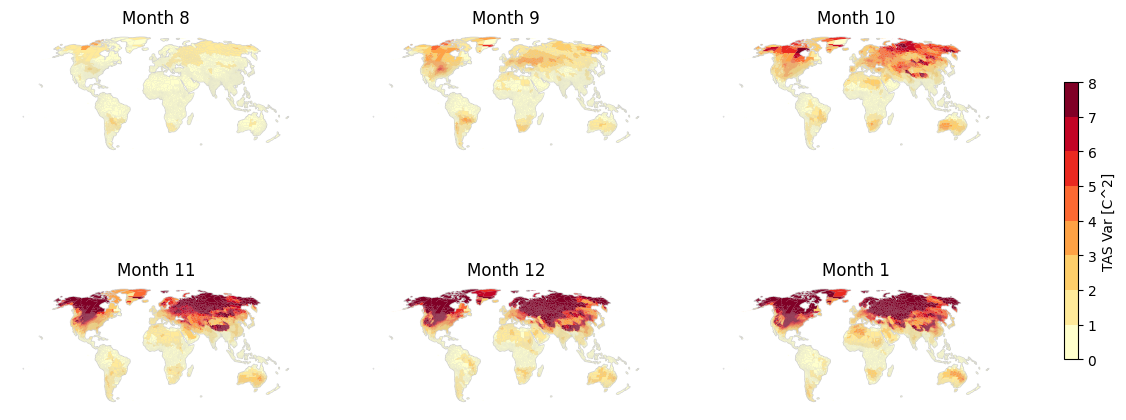

In [62]:
fig = analysis_utils.plot_monthly(
    _polygons_forecast_var,
    col='value',
    cm = 'YlOrRd',
    vmin = 0, vmax = 8, n_colors = 10,
    sup_title=f"",
    cbar_label= 'TAS Var [C^2]',
    month_order= [8, 9, 10, 11, 12, 1]
)
fig.savefig("figA4_2608_forecast_var.png", dpi = 600, bbox_inches="tight")

### Anomaly variance

In [65]:
_polygons_forecast_anomaly_var = analysis_utils.xarray_to_gpd(anomaly_ir.var(dim = "number"), _polygons)

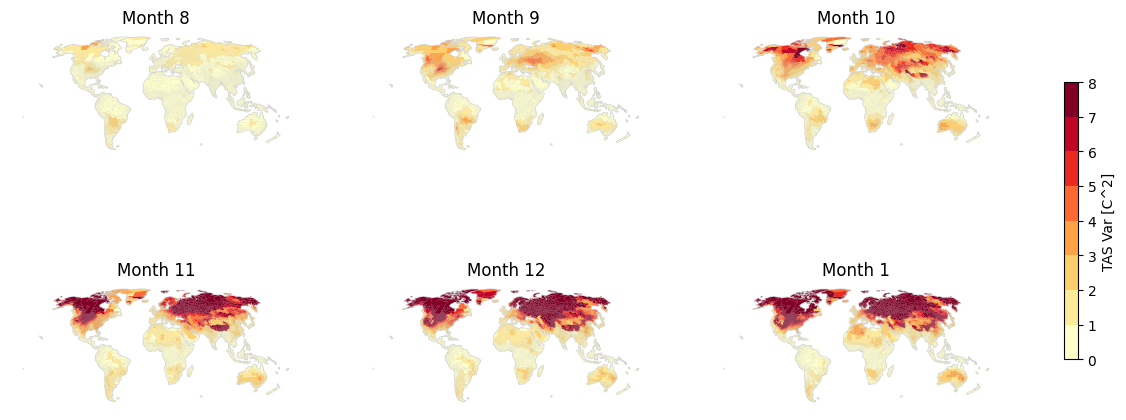

In [66]:
fig = analysis_utils.plot_monthly(
    _polygons_forecast_anomaly_var,
    col='value',
    cm = 'YlOrRd',
    vmin = 0, vmax = 8, n_colors = 10,
    sup_title=f"",
    cbar_label= 'TAS Var [C^2]',
    month_order= [8, 9, 10, 11, 12, 1]
)
fig.savefig("figA4_2608_forecast_anom_var.png", dpi = 600, bbox_inches="tight")

# Figure A6. 
Baseline age-weighted mean mortality rate by month: caption

In [ ]:
regional_sum = pop_weight_sum(impact, socioeconomics, rate=True, age_weight=age_weight, cohort = cohort, impact = True)

In [13]:
effect['/baseline']['effect']

<xarray.DataArray 'effect' (region: 24355, time: 360, sample: 15, age_cohort: 3)> Size: 2GB
[394551000 values with dtype=float32]
Coordinates:
  * region      (region) StringDType() 390kB 'ABW' ... 'ZWE.9.R19a261b63a503c9c'
  * time        (time) object 3kB 1996-01-01 00:00:00 ... 2025-12-01 00:00:00
  * sample      (sample) int64 120B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
  * age_cohort  (age_cohort) StringDType() 48B 'age0to4' 'age5to64' 'age65plus'
Attributes:
    units:      deaths per 100,000 people
    long_name:  Temperature mortality

# Figure A8. 
Change in age-weighted mean mortality rate by month: caption

In [67]:
impact = analysis_utils.compute_impact(effect, socioeconomics, ensemble = True, baseline_period=baseline_period, hotonly = "net", rate = True, age_weight = True)

In [69]:
_polygons_impact = analysis_utils.xarray_to_gpd(impact.mean(dim = ['number', 'sample']), _polygons)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_

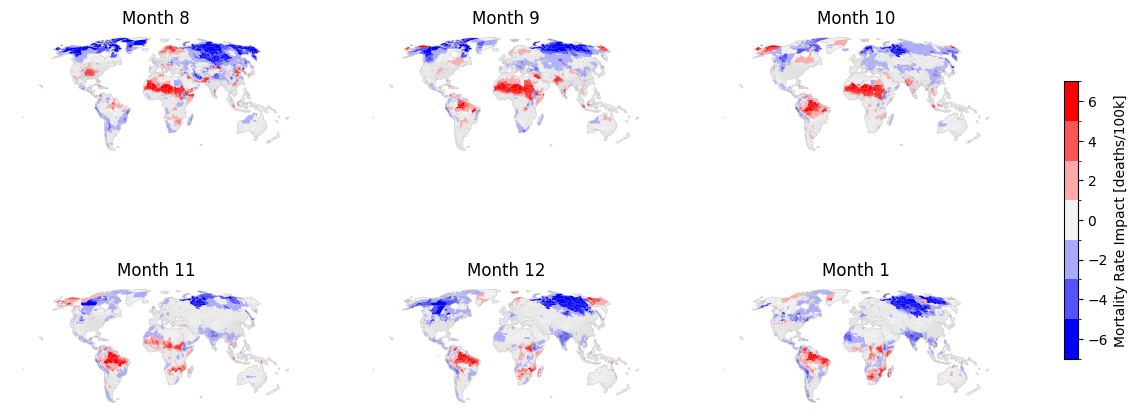

In [71]:
fig = analysis_utils.plot_monthly(
    _polygons_impact,
    col='age_weighted_impact',
    cm = 'bwr',
    sup_title=f"",
    cbar_label= 'Mortality Rate Impact [deaths/100k]',
    month_order= [8, 9, 10, 11, 12, 1]
)
fig.savefig("figA8_2608_monthly_rate_impact.png", dpi = 600, bbox_inches="tight")

# Figure A9. 
Forecast uncertainty standard deviation of change in age-weighted mean mortality rate by month: caption

In [72]:
_polygons_impact_std = analysis_utils.xarray_to_gpd(impact.std(dim = ['number', 'sample']), _polygons)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_

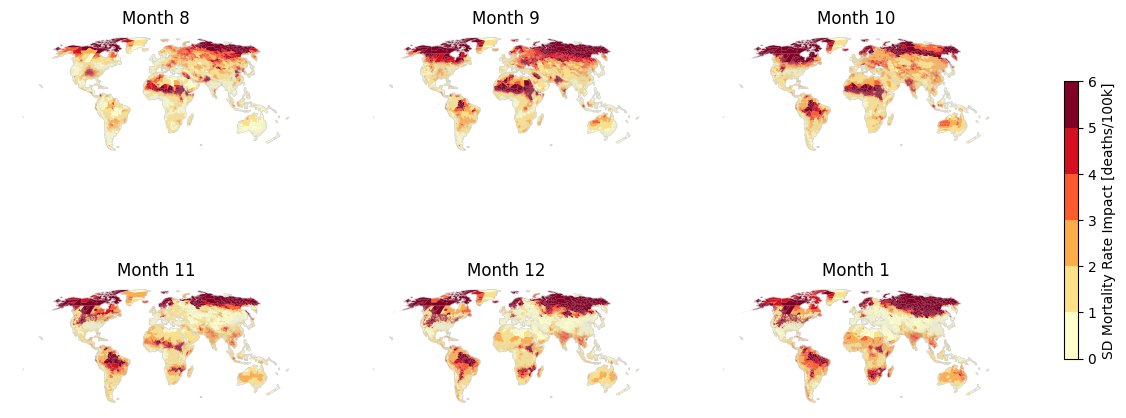

In [75]:
fig = analysis_utils.plot_monthly(
    _polygons_impact_std,
    col='age_weighted_impact',
    cm = 'YlOrRd',
    vmin = 0, vmax = 6,
    sup_title=f"",
    cbar_label= 'SD Mortality Rate Impact [deaths/100k]',
    month_order= [8, 9, 10, 11, 12, 1]
)
fig.savefig("figA9_2608_monthly_rate_impact_sd.png", dpi = 600, bbox_inches="tight")